# *In silico* perturbation

Depletes *LUM* in the stromal cells of the Xenium human breast cancer sections and quantifies the
predicted change in subcellular localization of a downstream gene.

Reads

- `{train,val,test}_xenium_breast_cancer.npz`, `gene_names.txt`,
  `gene2vec_weight_xenium_breast_cancer.npy`
- `checkpoint_Xenium_breast_cancer.pth` — the released checkpoint, from `../../../checkpoints`

Writes

- `lum_depletion_CRISPLD2.npz` — by `xenium_breast_cancer/perturb.py`

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

SVC_ROOT = Path(os.environ.get('SVC_ROOT', '../../..'))   # github.com/aster-ww/SVC

DATA_ROOT = Path(os.environ.get('SVC_DATA_ROOT', '../../../data'))
CKPT_DIR = Path('../../../checkpoints')
OUT_DIR = Path('../../../output/xenium_breast_cancer')

## *LUM* depletion

For every cell, the input of the depleted gene is clamped to its 5th percentile among the cells
of that set, and the same clamp is applied to that gene in the neighbor-expression context of
every neighboring cell. Each downstream gene is masked from the model input in a leave-one-out
manner, and the change in its subcellular localization after depletion is quantified.

In [2]:
!python {SVC_ROOT}/xenium_breast_cancer/perturb.py --data-root {DATA_ROOT} --ckpt {CKPT_DIR}/checkpoint_Xenium_breast_cancer.pth --deplete LUM --cell-types Stromal --genes CRISPLD2 --save-maps --out {OUT_DIR}/lum_depletion_CRISPLD2.npz

[train] 14931 of 54258 cells are ['Stromal']
[val] 1937 of 6656 cells are ['Stromal']
[test] 14772 of 43252 cells are ['Stromal']
LUM p5 = 9 counts, already at or below it in 6.1% of cells
1 downstream gene(s)
loaded epoch 148
  [train] 512/14931
  [train] 4608/14931
  [train] 8704/14931
  [train] 12800/14931
  [val] 512/1937
  [test] 512/14772
  [test] 4608/14772
  [test] 8704/14772
  [test] 12800/14772
saved ../../../output/xenium_breast_cancer/lum_depletion_CRISPLD2.npz  31640 cells x 1 gene(s)


## The subcellular response of *CRISPLD2*

The change in the SVC-predicted subcellular distribution of *CRISPLD2* upon *LUM* depletion, per
pixel and summed within six concentric rings. Averaged over cells as the per-pixel change in
mass fraction on the 12 x 12 image; each cell's map is normalized to sum to one before
averaging.

In [3]:
GENE, MIN_COUNTS = 'CRISPLD2', 5
CAP = 0.001
PH = 2.30                       # axes-box height in inches, identical in both files
EDGES = np.linspace(0, 1, 7)

result = np.load(OUT_DIR / 'lum_depletion_CRISPLD2.npz', allow_pickle=True)
column = list(result['genes']).index(GENE)
keep = result['truth_count'][:, column] >= MIN_COUNTS
map_before, map_after = result['map_before'][keep, column], result['map_after'][keep, column]

# each cell's map is normalized to sum to one before averaging
A = (map_before / map_before.sum((-1, -2), keepdims=True)).mean(0)
B = (map_after / map_after.sum((-1, -2), keepdims=True)).mean(0)
delta = B - A
ii, jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
radius = np.minimum(np.sqrt((ii + .5 - 6) ** 2 + (jj + .5 - 6) ** 2) / 6, 1)
foreground = A > 0                          # the 12 corner pixels are background in the SVC grid

DIV = LinearSegmentedColormap.from_list('div', ['#2166ac', '#f7f7f7', '#b2182b']).copy()
DIV.set_bad('white')

rect = lambda fw, fh, x, y, w, h: [x / fw, y / fh, w / fw, h / fh]

shift = result['distance_after'][keep, column] - result['distance_before'][keep, column]
print('%d of %d stromal cells carry at least %d measured %s transcripts'
      % (keep.sum(), len(keep), MIN_COUNTS, GENE))
print('mean change in distance to the nuclear center: %+.6f' % shift.mean())


4333 of 31640 stromal cells carry at least 5 measured CRISPLD2 transcripts
mean change in distance to the nuclear center: -0.004912


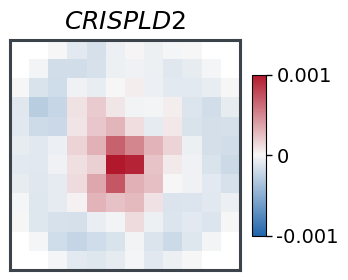

In [4]:
FW1, FH1 = 3.6, 2.95
X_MAP, Y1, GAP_CB, W_CB = 0.10, 0.10, 0.12, 0.14

fig = plt.figure(figsize=(FW1, FH1))
fig.patch.set_facecolor('white')
ax = fig.add_axes(rect(FW1, FH1, X_MAP, Y1, PH, PH))
im = ax.imshow(np.where(foreground, delta, np.nan), cmap=DIV, vmin=-CAP, vmax=CAP)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color('#3d434a'); spine.set_linewidth(2.2)
ax.set_title(f'$\\it{{{GENE}}}$', fontsize=18, pad=8, color='black')

cax = fig.add_axes(rect(FW1, FH1, X_MAP + PH + GAP_CB, Y1 + PH * 0.15, W_CB, PH * 0.70))
cb = fig.colorbar(im, cax=cax, ticks=[-CAP, 0, CAP])
cb.ax.set_yticklabels([f'{-CAP:g}', '0', f'{CAP:g}'])
cb.ax.tick_params(labelsize=14, length=4, width=1.0, colors='black')
plt.show()

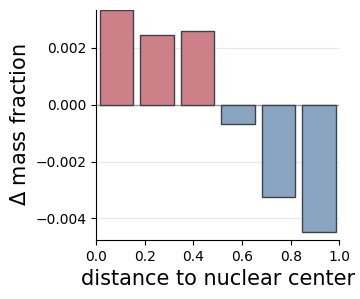

In [5]:
centers, ring_delta = [], []
for lo, hi in zip(EDGES[:-1], EDGES[1:]):
    m = foreground & (radius >= lo) & (radius < hi + (1e-9 if hi == 1 else 0))
    centers.append((lo + hi) / 2)
    ring_delta.append(delta[m].sum())
centers, ring_delta = np.array(centers), np.array(ring_delta)

FW2, FH2 = 3.6, 2.95
X_BAR, Y2 = 1.05, 0.62

fig = plt.figure(figsize=(FW2, FH2))
fig.patch.set_facecolor('white')
ax = fig.add_axes(rect(FW2, FH2, X_BAR, Y2, FW2 - X_BAR - 0.12, PH))
ax.axhline(0, color='#9aa0a6', lw=1.0, zorder=1)
ax.bar(centers, ring_delta, width=(EDGES[1] - EDGES[0]) * 0.82, zorder=2,
       color=['#ce8089' if v > 0 else '#89a5c2' for v in ring_delta],
       edgecolor='#3d434a', linewidth=1.0)
ax.set_xlabel('distance to nuclear center', fontsize=15, color='black')
ax.set_ylabel('$\\Delta$ mass fraction', fontsize=15, color='black')
ax.set_xlim(0, 1)
ax.set_ylim(ring_delta.min() * 1.06, ring_delta.max())
ax.tick_params(labelsize=10, colors='black')
ax.grid(axis='y', color='#e6e8ea', lw=0.9)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('black')
plt.show()